<a href="https://colab.research.google.com/github/RCutrino/cmapss_project/blob/main/notebook/03_rul_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMAPSS FD001 — RUL forecasting

## Objectives

- build baseline RUL forecasting models
- compare classical ML and DL approaches
- evaluate predictive performance
- identify the best-performing model

## Environment and Library Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, Markdown

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import sys
sys.path.append("..")
from src.RUL_forecasting import evaluate, nasa_score, make_sequences
from src.RUL_forecasting import build_lstm, build_bilstm

import joblib

import warnings
warnings.filterwarnings('ignore')

## Load data

In [ ]:
data_path = "../data/processed/"

In [ ]:
train_df = pd.read_parquet(os.path.join(data_path, "rul_train.parquet"))
print(train_df.shape)
print(train_df.columns)

(16020, 33)
Index(['engine_id', 'cycle', 'RUL', 'sensor_11', 'sensor_4', 'sensor_12',
       'sensor_7', 'sensor_21', 'sensor_11_rolling_mean',
       'sensor_4_rolling_mean', 'sensor_12_rolling_mean',
       'sensor_7_rolling_mean', 'sensor_21_rolling_mean',
       'sensor_11_rolling_std', 'sensor_4_rolling_std',
       'sensor_12_rolling_std', 'sensor_7_rolling_std',
       'sensor_21_rolling_std', 'sensor_11_lag_1', 'sensor_11_lag_2',
       'sensor_11_lag_3', 'sensor_4_lag_1', 'sensor_4_lag_2', 'sensor_4_lag_3',
       'sensor_12_lag_1', 'sensor_12_lag_2', 'sensor_12_lag_3',
       'sensor_7_lag_1', 'sensor_7_lag_2', 'sensor_7_lag_3', 'sensor_21_lag_1',
       'sensor_21_lag_2', 'sensor_21_lag_3'],
      dtype='object')


In [ ]:
val_df = pd.read_parquet(os.path.join(data_path, "rul_val.parquet"))
print(val_df.shape)
print(val_df.columns)

(4211, 33)
Index(['engine_id', 'cycle', 'RUL', 'sensor_11', 'sensor_4', 'sensor_12',
       'sensor_7', 'sensor_21', 'sensor_11_rolling_mean',
       'sensor_4_rolling_mean', 'sensor_12_rolling_mean',
       'sensor_7_rolling_mean', 'sensor_21_rolling_mean',
       'sensor_11_rolling_std', 'sensor_4_rolling_std',
       'sensor_12_rolling_std', 'sensor_7_rolling_std',
       'sensor_21_rolling_std', 'sensor_11_lag_1', 'sensor_11_lag_2',
       'sensor_11_lag_3', 'sensor_4_lag_1', 'sensor_4_lag_2', 'sensor_4_lag_3',
       'sensor_12_lag_1', 'sensor_12_lag_2', 'sensor_12_lag_3',
       'sensor_7_lag_1', 'sensor_7_lag_2', 'sensor_7_lag_3', 'sensor_21_lag_1',
       'sensor_21_lag_2', 'sensor_21_lag_3'],
      dtype='object')


## Define features & target

The processed dataset already contains all engineered features from notebook 02:
raw sensor readings, rolling statistics (mean & std), and lag features.

`engine_id` and `cycle` are dropped as identifiers.  
`RUL` is the regression target.

In [ ]:
TARGET = 'RUL'
DROP   = ['engine_id', 'cycle', 'RUL']
FEATURES = [col for col in train_df.columns if col not in DROP]

In [ ]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_val   = val_df[FEATURES]
y_val   = val_df[TARGET]

In [ ]:
print(f"Features : {len(FEATURES)}")
print(f"X_train  : {X_train.shape}")
print(f"X_val    : {X_val.shape}")
print()
print(FEATURES)

Features : 30
X_train  : (16020, 30)
X_val    : (4211, 30)

['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_21', 'sensor_11_rolling_mean', 'sensor_4_rolling_mean', 'sensor_12_rolling_mean', 'sensor_7_rolling_mean', 'sensor_21_rolling_mean', 'sensor_11_rolling_std', 'sensor_4_rolling_std', 'sensor_12_rolling_std', 'sensor_7_rolling_std', 'sensor_21_rolling_std', 'sensor_11_lag_1', 'sensor_11_lag_2', 'sensor_11_lag_3', 'sensor_4_lag_1', 'sensor_4_lag_2', 'sensor_4_lag_3', 'sensor_12_lag_1', 'sensor_12_lag_2', 'sensor_12_lag_3', 'sensor_7_lag_1', 'sensor_7_lag_2', 'sensor_7_lag_3', 'sensor_21_lag_1', 'sensor_21_lag_2', 'sensor_21_lag_3']


## Evaluation metrics (RMSE, MAE, R², NASA score)

Models are evaluated with four metrics:

- **RMSE** — penalises large errors more than MAE
- **MAE** — average absolute error in cycles
- **R²** — proportion of variance explained
- **NASA Score** — asymmetric scoring function from the original CMAPSS paper. Penalises *late* predictions (underestimating RUL) more than *early* ones, reflecting the real cost of unexpected failures.

In [ ]:
results = {}

## Baseline model (Mean predictor, Linear Regression)


Two simple baselines establish the minimum performance bar:

- **Mean Predictor** — always predicts the mean RUL of the training set. Any useful model must beat this.
- **Linear Regression** — simplest parametric model, assumes a linear relationship between features and RUL.

In [ ]:
# Mean Predictor
mean_pred = np.full(len(y_val), y_train.mean())
evaluate('Mean Predictor', y_val, mean_pred, results);

Mean Predictor            RMSE=71.09  MAE=58.15  R²=-0.006  NASA=762406783.8


In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
evaluate('Linear Regression', y_val, lr.predict(X_val), results);

Linear Regression         RMSE=46.71  MAE=35.32  R²=0.566  NASA=45499122.7


## Classical ML (Random Forest, XGBoost)


Tree-based models that handle non-linearity and feature interactions without requiring manual feature engineering.

- **Random Forest** — ensemble of decorrelated decision trees, robust to overfitting thanks to bagging.
- **XGBoost** — gradient boosting with regularisation, typically the strongest classical ML model on tabular data.

Hyperparameters tuned via a light random search on the validation set.

### Random Forest

In [ ]:
rf_params = {'n_estimators': [100, 200, 300],
             'max_depth': [6, 10, 15, None],
             'min_samples_split': [2, 5, 10],
             'max_features': ['sqrt', 'log2']}

In [ ]:
rf = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                        rf_params,
                        n_iter=20,
                        cv=3,
                        scoring='neg_root_mean_squared_error',
                        random_state=42,
                        n_jobs=-1,
                        verbose=0)

In [ ]:
rf.fit(X_train, y_train)
print(f"RF  best params : {rf.best_params_}")

RF  best params : {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 6}


In [ ]:
evaluate('Random Forest', y_val, rf.best_estimator_.predict(X_val), results);

Random Forest             RMSE=46.17  MAE=33.91  R²=0.576  NASA=43746403.2


### XGBoost

In [ ]:
xgb_params = {'n_estimators': [100, 200, 300],
              'max_depth': [3, 5, 7],
              'learning_rate': [0.01, 0.05, 0.1],
              'subsample': [0.7, 0.8, 1.0],
              'colsample_bytree': [0.7, 0.8, 1.0]}

In [ ]:
xgb_model = RandomizedSearchCV(xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
                               xgb_params,
                               n_iter=20,
                               cv=3,
                               scoring='neg_root_mean_squared_error',
                               random_state=42,
                               n_jobs=-1,
                               verbose=0)

In [ ]:
xgb_model.fit(X_train, y_train)
print(f"XGB best params : {xgb_model.best_params_}")

XGB best params : {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [ ]:
evaluate('XGBoost', y_val, xgb_model.best_estimator_.predict(X_val), results);

XGBoost                   RMSE=46.46  MAE=34.25  R²=0.570  NASA=54252814.4


## Sequence preparation (sliding window per LSTM)

LSTM models require 3D input of shape `(samples, timesteps, features)`.

A sliding window of length `SEQ_LEN = 30` is built **per engine** to preserve temporal order and avoid mixing cycles from different engines.

For the sequence features only the **5 raw sensors** are used — rolling and lag features are redundant here since the LSTM learns temporal dependencies directly
from the sequence.

In [ ]:
SEQ_LEN = 30
SEQ_SENSORS = [col for col in train_df.columns
               if col.startswith('sensor')
               and '_rolling' not in col
               and '_lag' not in col]

In [ ]:
X_train_seq, y_train_seq = make_sequences(train_df, SEQ_SENSORS, 'RUL', SEQ_LEN)
X_val_seq, y_val_seq = make_sequences(val_df,   SEQ_SENSORS, 'RUL', SEQ_LEN)

In [ ]:
print(f"X_train_seq : {X_train_seq.shape}  → (samples, timesteps, features)")
print(f"X_val_seq : {X_val_seq.shape}")

X_train_seq : (13700, 30, 5)  → (samples, timesteps, features)
X_val_seq : (3631, 30, 5)


## Deep Learning (LSTM, Bidirectional LSTM)


Both models share the same architecture pattern — two recurrent layers with dropout and a dense head — differing only in the use of bidirectionality.

- **LSTM** — processes the sequence forward, capturing degradation trends over time.
- **Bidirectional LSTM** — processes the sequence in both directions, giving each   timestep context from past and future cycles within the window.

Early stopping on validation loss prevents overfitting.

In [ ]:
INPUT_SHAPE = (SEQ_LEN, len(SEQ_SENSORS))

In [ ]:
callbacks = [EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True,
                           verbose=1),
             ReduceLROnPlateau(monitor='val_loss',
                               factor=0.5,
                               patience=5,
                               min_lr=1e-5,
                               verbose=1)]

### LSTM

In [ ]:
EPOCHS = 100
BATCH  = 256

In [ ]:
lstm   = build_lstm(INPUT_SHAPE)

In [ ]:
lstm.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = lstm.fit(X_train_seq,
                        y_train_seq,
                        validation_data=(X_val_seq, y_val_seq),
                        epochs=EPOCHS,
                        batch_size=BATCH,
                        callbacks=callbacks,
                        verbose=1)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 10351.4893 - mae: 83.5061 - val_loss: 9897.3516 - val_mae: 78.4494 - learning_rate: 0.0010
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 7233.6392 - mae: 66.0312 - val_loss: 6909.2266 - val_mae: 63.7598 - learning_rate: 0.0010
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4939.7285 - mae: 54.3417 - val_loss: 4953.9155 - val_mae: 54.6621 - learning_rate: 0.0010
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3888.9331 - mae: 49.6639 - val_loss: 4269.1436 - val_mae: 52.0273 - learning_rate: 0.0010
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3674.4653 - mae: 49.1309 - val_loss: 4148.2681 - val_mae: 51.7807 - learning_rate: 0.0010
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3641.5022 - mae: 49.1291 - val_loss: 4134.7803 - val_mae: 51.7774 - learning_rate: 0.0010
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3636.0876 - mae: 49.0996 - val_loss: 41

In [ ]:
evaluate('LSTM', y_val_seq, lstm.predict(X_val_seq).flatten(), results);

114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
LSTM                      RMSE=34.14  MAE=23.05  R²=0.715  NASA=12919979.7


### Bidirectional LSTM

In [ ]:
bilstm = build_bilstm(INPUT_SHAPE)

In [ ]:
bilstm.summary()

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       137,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,729 (1.17 MB)

 Trainable params: 305,729 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_bilstm = bilstm.fit(X_train_seq,
                            y_train_seq,
                            validation_data=(X_val_seq, y_val_seq),
                            epochs=EPOCHS,
                            batch_size=BATCH,
                            callbacks=callbacks,
                            verbose=1)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 10031.3398 - mae: 81.3350 - val_loss: 9193.6543 - val_mae: 75.0437 - learning_rate: 0.0010
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 6293.7344 - mae: 61.0518 - val_loss: 5587.7490 - val_mae: 56.3488 - learning_rate: 0.0010
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3572.4663 - mae: 43.8533 - val_loss: 3244.2141 - val_mae: 40.1902 - learning_rate: 0.0010
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2075.3027 - mae: 31.5121 - val_loss: 1937.4993 - val_mae: 29.2450 - learning_rate: 0.0010
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1465.4424 - mae: 26.2554
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1397.2323 - mae: 25.3683 - val_loss: 1512.5675 - val_mae: 25.4839 - learning_rate: 0.0010
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1178.7559 - mae: 22.9419 - val_loss: 146

In [ ]:
evaluate('BiLSTM', y_val_seq, bilstm.predict(X_val_seq).flatten(), results);

114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
BiLSTM                    RMSE=95.88  MAE=75.04  R²=-1.244  NASA=36691217031.0


## Model comparison (tabella + grafico)


Summary of all models evaluated on the validation set.  

Lower RMSE and NASA Score are better; higher R² is better.

In [ ]:
results_df = (pd.DataFrame(results).T.sort_values('RMSE').round(3))
display(results_df)

,RMSE,MAE,R²,NASA Score
LSTM,34.143,23.053,0.715,1.291998e+07
Random Forest,46.167,33.907,0.576,4.374640e+07
XGBoost,46.457,34.248,0.570,5.425281e+07
Linear Regression,46.708,35.321,0.566,4.549912e+07
Mean Predictor,71.089,58.147,-0.006,7.624068e+08
BiLSTM,95.884,75.044,-1.244,3.669122e+10


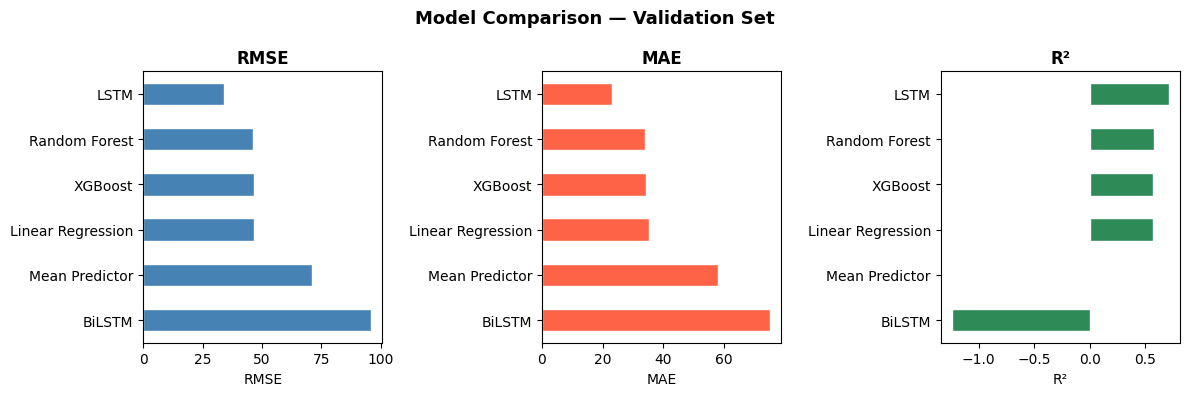

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics   = ['RMSE', 'MAE', 'R²']
colors    = ['steelblue', 'tomato', 'seagreen']

for ax, metric, color in zip(axes, metrics, colors):
    results_df[metric].plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle('Model Comparison — Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_model_comparison.png', bbox_inches='tight')
plt.show()

### Results

LSTM is the best performing model (RMSE = 34.14, R² = 0.715), outperforming all classical ML models by a significant margin.

Random Forest, XGBoost and Linear Regression are closely clustered
(RMSE ≈ 46–47), suggesting that the engineered features — rolling statistics and lag features — already capture most of the temporal information available to tabular models.

Surprisingly, BiLSTM underperforms even the Mean Predictor (R² = -1.244).

This is likely due to the limited size of FD001, which is insufficient for a bidirectional architecture to generalise — processing sequences in both directions increases model complexity without a proportional gain in information on this dataset.

The NASA Score confirms LSTM as the best model, with a considerably lower cumulative penalty than all other approaches.

## Error & residual analysis


A deeper look at the best model (LSTM) to understand where and how it fails.

- **Predicted vs Actual** — how closely predictions follow the ideal line
- **Residual distribution** — whether errors are symmetric and centered on zero
- **Residuals vs RUL** — whether errors are uniform across the degradation curve or concentrated in specific phases (early life vs near failure)

In [ ]:
best_preds = lstm.predict(X_val_seq).flatten()

114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
residuals  = y_val_seq - best_preds

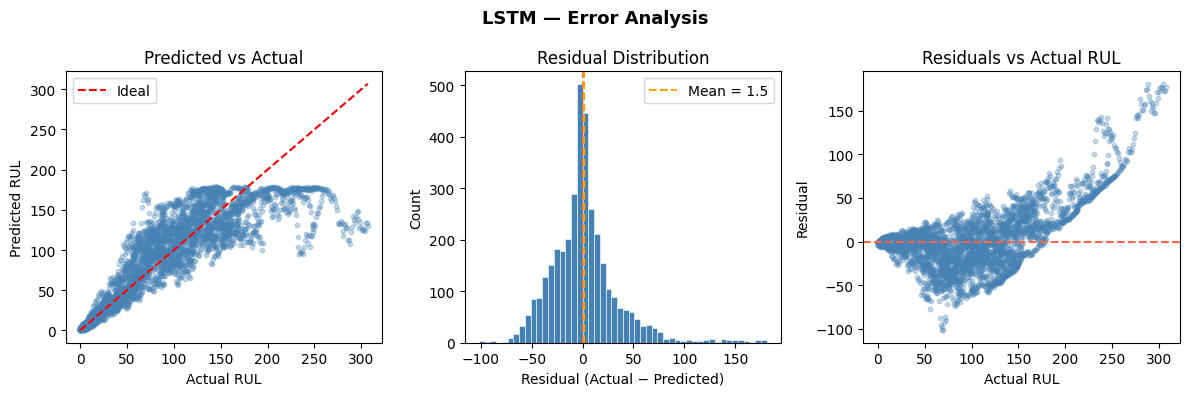

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Predicted vs Actual
axes[0].scatter(y_val_seq, best_preds, alpha=0.3, s=10, color='steelblue')
lims = [0, y_val_seq.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# Residual distribution
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='tomato', linestyle='--', linewidth=1.5)
axes[1].axvline(residuals.mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean = {residuals.mean():.1f}')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].legend()

# Residuals vs Actual RUL
axes[2].scatter(y_val_seq, residuals, alpha=0.3, s=10, color='steelblue')
axes[2].axhline(0, color='tomato', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Actual RUL')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Actual RUL')

plt.suptitle('LSTM — Error Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_error_analysis.png', bbox_inches='tight')
plt.show()

### Observations
**Predicted vs Actual** — the model tracks the ideal line well for RUL < 125, but predictions plateau around 125–150 for higher actual values.  
This is the direct effect of the piecewise-linear cap applied during training: the model never learned to predict RUL beyond the cap.

**Residual Distribution** — nearly symmetric and centered at 1.5, indicating the model is essentially unbiased. The slight right skew confirms a small tendency to overestimate RUL near the cap boundary.

**Residuals vs Actual RUL** — residuals are close to zero for low RUL values (near-failure phase), where prediction matters most.  
For high RUL values the residuals grow positive, confirming the cap effect: actual RUL can reach ~300 in the validation set but the model is bounded by what it saw during training.  
This is expected and acceptable behaviour — early-life prediction is less critical than near-failure accuracy.

## Feature importance (RF + XGBoost)

Feature importance is extracted from the two best classical ML models:
- **Random Forest** (impurity-based)
- **XGBoost** (gain-based).

Neural networks are excluded as their internal representations are not directly interpretable in this way.

In [ ]:
importance_rf  = pd.Series(rf.best_estimator_.feature_importances_,
                           index=FEATURES)
importance_xgb = pd.Series(xgb_model.best_estimator_.feature_importances_,
                           index=FEATURES)

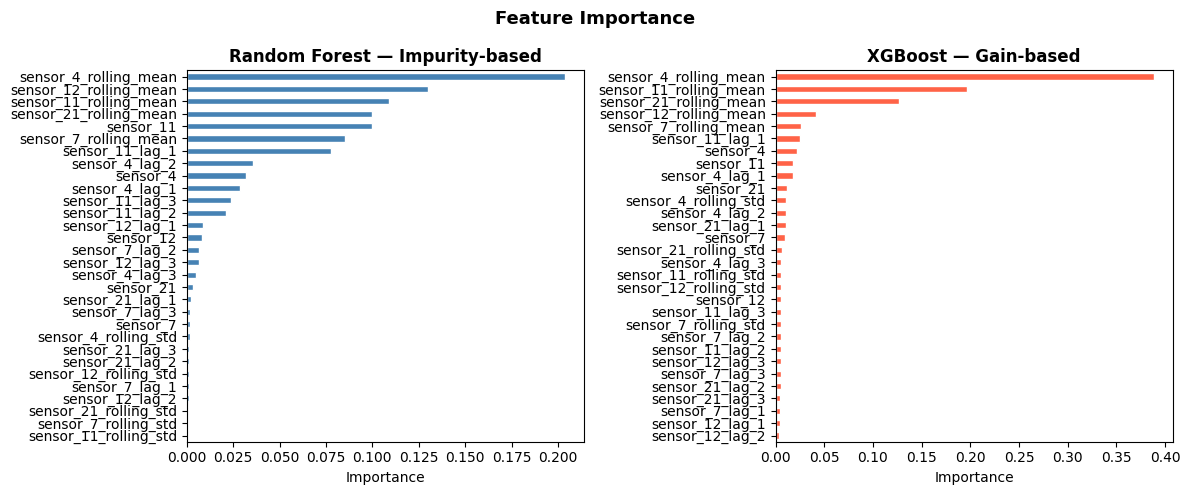

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, importance, title, color in zip(axes,
                                        [importance_rf, importance_xgb],
                                        ['Random Forest — Impurity-based', 'XGBoost — Gain-based'],
                                        ['steelblue', 'tomato']):
    importance.sort_values().plot(kind='barh',
                                  ax=ax,
                                  color=color,
                                  edgecolor='white')
    ax.set_title(title,
                 fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance',
             fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_feature_importance.png', bbox_inches='tight')
plt.show()

### Observations

Both models agree on the dominant feature: **sensor_4_rolling_mean**
(importance ≈ 0.20 in RF, ≈ 0.38 in XGBoost), which alone accounts for a disproportionate share of predictive power.

**Rolling means consistently outrank all other feature groups** — raw sensor readings, lag features and rolling std — in both models.  
This confirms that the smoothed degradation trend carries more signal than instantaneous readings or short-term variability.

**Lag features** contribute moderately and uniformly, suggesting that recent history adds value but is largely redundant with the rolling mean already capturing the same temporal trend at a coarser scale.

**Rolling std features rank last** in both models, indicating that sensor variability is not a strong predictor of RUL on FD001 — likely because this subset has a single operating condition and a single fault mode, which produces a smooth, low-noise degradation curve with little variability to exploit.

The strong agreement between RF and XGBoost on feature rankings increases confidence that these findings reflect genuine signal in the data rather than model-specific artefacts.

## Save best model

The LSTM is saved in native Keras format for later use in the pipeline.  
Classical ML models are serialised with joblib.  
The results table is exported as CSV for reference in subsequent notebooks.

In [ ]:
lstm.save('../outputs/RUL_forecasting_model/lstm_rul_fd001.keras')
print('Saved: ../outputs/RUL_forecasting_model/lstm_rul_fd001.keras')

Saved: ../outputs/RUL_forecasting_model/lstm_rul_fd001.keras


In [ ]:
joblib.dump(rf.best_estimator_, '../outputs/RUL_forecasting_model/rf_rul_fd001.pkl')
joblib.dump(xgb_model.best_estimator_, '../outputs/RUL_forecasting_model/xgb_rul_fd001.pkl')
print('Saved: ../outputs/RUL_forecasting_model/rf_rul_fd001.pkl')
print('Saved: ../outputs/RUL_forecasting_model/xgb_rul_fd001.pkl')

Saved: ../outputs/RUL_forecasting_model/rf_rul_fd001.pkl
Saved: ../outputs/RUL_forecasting_model/xgb_rul_fd001.pkl


In [ ]:
results_df.to_csv('../outputs/RUL_forecasting_model/rul_model_results.csv')
joblib.dump(FEATURES, '../outputs/RUL_forecasting_model/features.pkl')
joblib.dump(SEQ_SENSORS, '../outputs/RUL_forecasting_model/seq_sensors.pkl')
print('Saved: ../outputs/RUL_forecasting_model/rul_model_results.csv')
print('Saved: ../outputs/RUL_forecasting_model/features.pkl')
print('Saved: ../outputs/RUL_forecasting_model/seq_sensors.pkl')

Saved: ../outputs/RUL_forecasting_model/rul_model_results.csv
Saved: ../outputs/RUL_forecasting_model/features.pkl
Saved: ../outputs/RUL_forecasting_model/seq_sensors.pkl
